# Análisis Exploratorio del Dataset — Detección de Grietas

**TP Final — Visión por Computadora II — CEIA (Grupo 5)**
Biancardi Agustín · Quiroga Gabriel · Vignolo Alan

**Objetivo del proyecto:** detección automática de grietas en superficies de infraestructura civil.
**Tarea principal:** detección de objetos (YOLO). Posible complemento: clasificación por severidad según tamaño de la grieta.

Este notebook analiza el **dataset de detección** (`dataset_9000_yolo`) y de forma resumida el **dataset de segmentación** (`dataset_1000`, DeepCrack) para justificar decisiones de diseño en el paper.

> **Nota de preprocesamiento.** La exportación original de Roboflow (YOLOv11) escribía las anotaciones como polígonos (formato de segmentación), aunque las grietas están anotadas como cajas rectangulares. El 65 % de las líneas tenían >5 campos y un lector de detección estándar las habría descartado. Se convirtieron todos los polígonos a *bounding boxes* (min/max de coordenadas), recuperando **29.791 anotaciones** (vs. 10.443 legibles en el export crudo), sin pérdida de información (los polígonos eran rectángulos). El dataset resultante (`dataset_9000_yolo`) valida sin errores con Ultralytics y usa una única clase `crack`.

---

## 1. Configuración e imports

In [1]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Raíz del proyecto (el notebook vive en src/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
DATASETS = PROJECT_ROOT / "datasets"
DET_ROOT = DATASETS / "dataset_9000_yolo"  # detección (YOLO, labels convertidos a bbox)
SEG_ROOT = DATASETS / "dataset_1000"       # segmentación (DeepCrack)

assert DET_ROOT.exists(), f"No encuentro {DET_ROOT}"
print("Proyecto :", PROJECT_ROOT)
print("Detección:", DET_ROOT)
print("Segment. :", SEG_ROOT)

Proyecto : d:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii
Detección: d:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\datasets\dataset_9000_yolo
Segment. : d:\ESTUDIOS\posgrado\Materias\CEIA (4) Vision por computadora II\tp_computer_vision_ii\datasets\dataset_1000


## 2. Dataset de detección (`dataset_9000`, formato YOLO)

Estructura esperada: `train|valid|test` con subcarpetas `images/` y `labels/`.
Cada label es un `.txt` con una línea por objeto: `clase x_centro y_centro ancho alto` (todo normalizado 0–1).

In [2]:
IMG_EXTS = {".jpg", ".jpeg", ".png"}
SPLITS = ["train", "valid", "test"]

def read_yolo_label(path):
    """Devuelve lista de (cls, xc, yc, w, h) normalizados. Vacío si no hay grietas."""
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        cls, xc, yc, w, h = parts
        rows.append((int(float(cls)), float(xc), float(yc), float(w), float(h)))
    return rows

records = []          # una fila por bounding box
img_records = []      # una fila por imagen

for split in SPLITS:
    img_dir = DET_ROOT / split / "images"
    lbl_dir = DET_ROOT / split / "labels"
    if not img_dir.exists():
        print(f"[aviso] no existe {img_dir}")
        continue
    for img_path in sorted(img_dir.iterdir()):
        if img_path.suffix.lower() not in IMG_EXTS:
            continue
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        boxes = read_yolo_label(lbl_path)
        with Image.open(img_path) as im:
            W, H = im.size
        img_records.append({
            "split": split, "file": img_path.name,
            "img_w": W, "img_h": H, "n_boxes": len(boxes),
        })
        for (cls, xc, yc, bw, bh) in boxes:
            records.append({
                "split": split, "file": img_path.name,
                "cls": cls,
                "xc": xc, "yc": yc, "w": bw, "h": bh,
                # tamaños en píxeles
                "w_px": bw * W, "h_px": bh * H,
                "area_px": bw * W * bh * H,
                "area_frac": bw * bh,                 # fracción del área de la imagen
                "aspect": (bw * W) / (bh * H + 1e-9),  # ancho/alto
            })

df = pd.DataFrame(records)      # boxes
imgs = pd.DataFrame(img_records)  # imágenes
print(f"Imágenes: {len(imgs)}  |  Bounding boxes: {len(df)}")
df.head()

Imágenes: 9947  |  Bounding boxes: 29791


,split,file,cls,xc,yc,w,h,w_px,h_px,area_px,area_frac,aspect
0,train,-2_jpg.rf.zdgshYebeJpslO5kJqwx.jpg,0,0.192188,0.471094,0.353125,0.406250,226.00000,260.00000,58760.00000,0.143457,0.869231
1,train,-2_jpg.rf.zdgshYebeJpslO5kJqwx.jpg,0,0.493750,0.794531,0.218750,0.410938,140.00000,263.00032,36820.04480,0.089893,0.532319
2,train,-2_jpg.rf.zdgshYebeJpslO5kJqwx.jpg,0,0.619531,0.666406,0.237500,0.621875,152.00000,398.00000,60496.00000,0.147695,0.381910
3,train,-4_jpg.rf.lsIjYtfIQXlQduBRx7p9.jpg,0,0.438281,0.392969,0.239063,0.709375,153.00032,454.00000,69462.14528,0.169585,0.337005
4,train,-4_jpg.rf.lsIjYtfIQXlQduBRx7p9.jpg,0,0.560156,0.880469,0.398438,0.239063,255.00032,153.00032,39015.13056,0.095252,1.666665


### 2.1 Tamaño de cada split y balance

In [3]:
split_summary = (
    imgs.groupby("split")
        .agg(imagenes=("file", "count"),
             imgs_sin_grieta=("n_boxes", lambda s: int((s == 0).sum())),
             total_boxes=("n_boxes", "sum"),
             boxes_por_img_media=("n_boxes", "mean"))
        .reindex(SPLITS)
)
split_summary["boxes_por_img_media"] = split_summary["boxes_por_img_media"].round(2)
split_summary["% del total"] = (split_summary["imagenes"] / split_summary["imagenes"].sum() * 100).round(1)
split_summary

,imagenes,imgs_sin_grieta,total_boxes,boxes_por_img_media,% del total
split,,,,,
train,5248,1,18647,3.55,52.8
valid,3058,0,8515,2.78,30.7
test,1641,0,2629,1.60,16.5


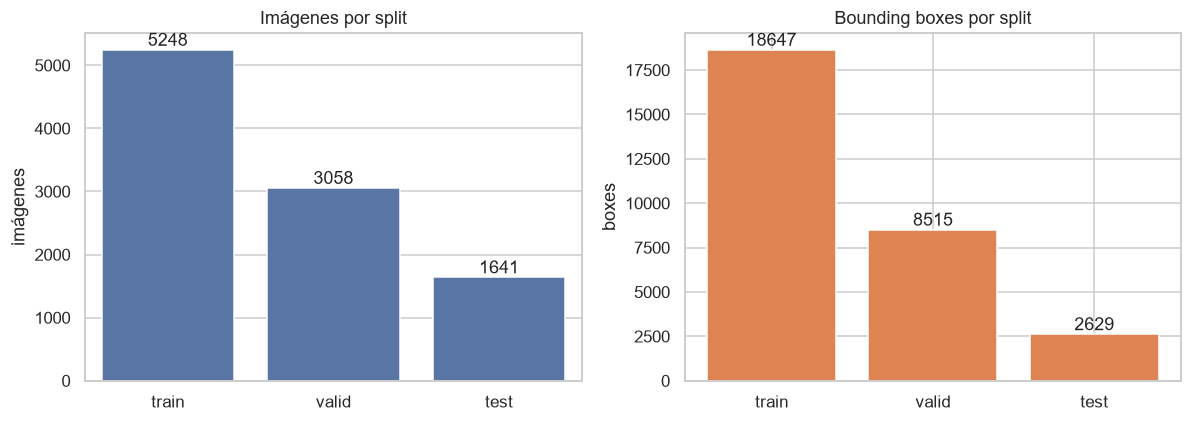

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
order = [s for s in SPLITS if s in imgs["split"].unique()]
sns.countplot(data=imgs, x="split", order=order, ax=ax[0], color="#4C72B0")
ax[0].set_title("Imágenes por split"); ax[0].set_xlabel(""); ax[0].set_ylabel("imágenes")
for c in ax[0].containers: ax[0].bar_label(c)

box_by_split = df.groupby("split").size().reindex(order)
ax[1].bar(box_by_split.index, box_by_split.values, color="#DD8452")
ax[1].set_title("Bounding boxes por split"); ax[1].set_ylabel("boxes")
ax[1].bar_label(ax[1].containers[0])
plt.tight_layout(); plt.show()

### 2.2 Clases presentes

Según `data.yaml` el dataset tiene **una sola clase** (`nc: 1`). Verificamos.

In [5]:
import yaml
with open(DET_ROOT / "data.yaml") as f:
    data_yaml = yaml.safe_load(f)
print("nc   :", data_yaml.get("nc"))
print("names:", data_yaml.get("names"))
print("clases realmente usadas en los labels:", sorted(df['cls'].unique()))
print(df["cls"].value_counts())

nc   : 1
names: ['crack']
clases realmente usadas en los labels: [np.int64(0)]
cls
0    29791
Name: count, dtype: int64


### 2.3 Grietas por imagen

Cuántos objetos hay por imagen. Útil para dimensionar el problema (¿imágenes con una sola grieta grande o muchas grietas chicas?).

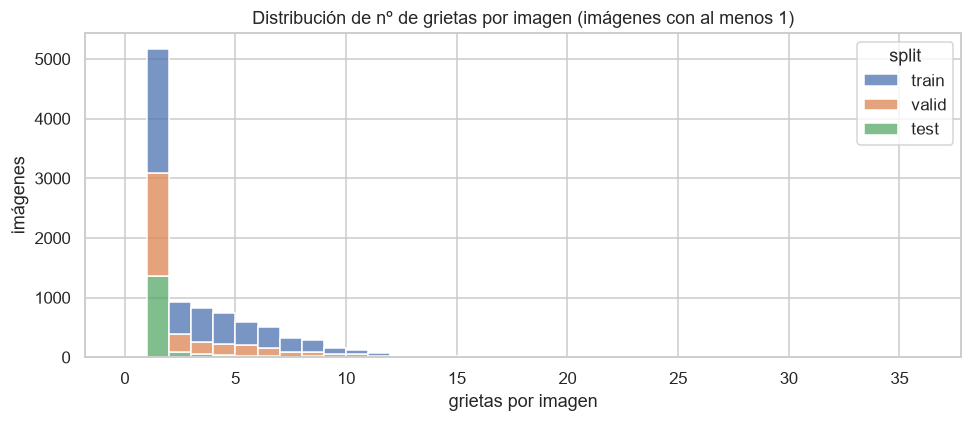

Estadísticas de grietas por imagen (todas las imágenes):
count    9947.00
mean        2.99
std         3.08
min         0.00
25%         1.00
50%         1.00
75%         4.00
max        35.00
Name: n_boxes, dtype: float64

Imágenes sin ninguna grieta (fondo puro): 1 (0.0%)


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=imgs[imgs.n_boxes > 0], x="n_boxes", bins=range(0, imgs.n_boxes.max() + 2),
             hue="split", multiple="stack", ax=ax)
ax.set_title("Distribución de nº de grietas por imagen (imágenes con al menos 1)")
ax.set_xlabel("grietas por imagen"); ax.set_ylabel("imágenes")
plt.tight_layout(); plt.show()

print("Estadísticas de grietas por imagen (todas las imágenes):")
print(imgs["n_boxes"].describe().round(2))
n_empty = int((imgs["n_boxes"] == 0).sum())
print(f"\nImágenes sin ninguna grieta (fondo puro): {n_empty} "
      f"({n_empty/len(imgs)*100:.1f}%)")

### 2.4 Resolución de las imágenes

Roboflow suele exportar a un tamaño fijo. Confirmamos que sea homogéneo (importa para elegir `imgsz` en YOLO).

In [7]:
res = imgs.groupby(["img_w", "img_h"]).size().reset_index(name="count").sort_values("count", ascending=False)
print("Resoluciones presentes:")
print(res.to_string(index=False))

Resoluciones presentes:
 img_w  img_h  count
   640    640   9941
   275    183      1
   480    480      1
   739   1016      1
   750    421      1
   768   1024      1
   999    562      1


### 2.5 Tamaño de las grietas (bounding boxes)

Clave para tu idea de **clasificar por severidad según tamaño**. Analizamos el área de la caja como fracción de la imagen, y sus dimensiones en píxeles.

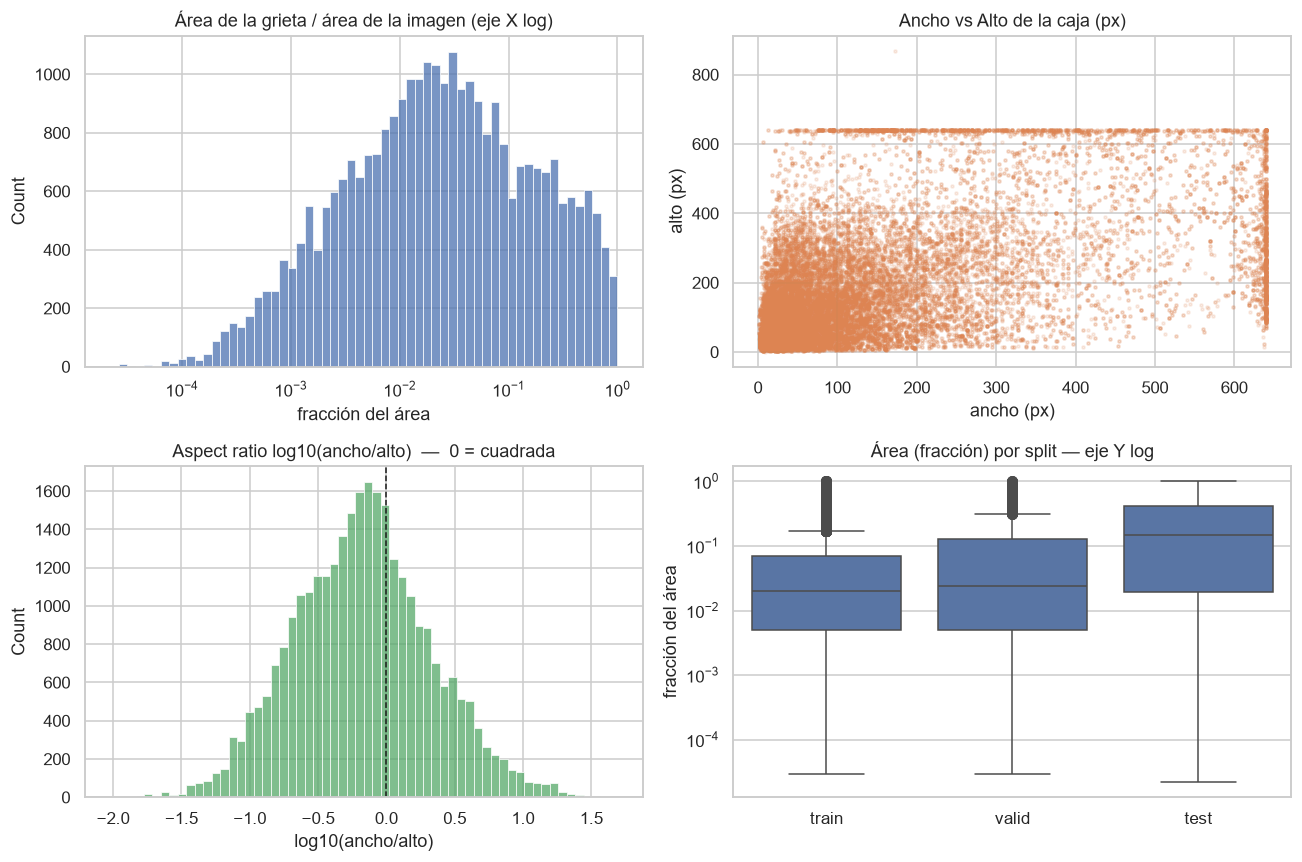

Estadísticas de tamaño de las cajas:
            w_px       h_px     area_px  area_frac
count  29791.000  29791.000   29791.000  29791.000
mean     149.434    186.811   42467.905      0.104
std      167.170    169.194   74202.251      0.181
min        1.000      1.000       9.003      0.000
25%       34.000     60.000    2236.000      0.005
50%       84.000    132.000    9600.000      0.023
75%      196.000    258.090   41398.000      0.101
max      640.000    868.580  409600.000      1.000


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Área como fracción de la imagen (escala log para ver la cola de grietas chicas)
sns.histplot(df["area_frac"], bins=60, ax=axes[0, 0], color="#4C72B0", log_scale=(True, False))
axes[0, 0].set_title("Área de la grieta / área de la imagen (eje X log)")
axes[0, 0].set_xlabel("fracción del área")

# Ancho vs alto en píxeles
axes[0, 1].scatter(df["w_px"], df["h_px"], s=4, alpha=0.15, color="#DD8452")
axes[0, 1].set_title("Ancho vs Alto de la caja (px)")
axes[0, 1].set_xlabel("ancho (px)"); axes[0, 1].set_ylabel("alto (px)")

# Aspect ratio (ancho/alto): >1 grietas horizontales, <1 verticales
sns.histplot(np.log10(df["aspect"]), bins=60, ax=axes[1, 0], color="#55A868")
axes[1, 0].axvline(0, color="k", ls="--", lw=1)
axes[1, 0].set_title("Aspect ratio log10(ancho/alto)  —  0 = cuadrada")
axes[1, 0].set_xlabel("log10(ancho/alto)")

# Boxplot del área por split
sns.boxplot(data=df, x="split", y="area_frac", order=order, ax=axes[1, 1])
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Área (fracción) por split — eje Y log")
axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("fracción del área")

plt.tight_layout(); plt.show()

print("Estadísticas de tamaño de las cajas:")
print(df[["w_px", "h_px", "area_px", "area_frac"]].describe().round(3))

### 2.6 Propuesta de categorías de severidad (borrador)

Para el complemento de "severidad por tamaño", dividimos las cajas en terciles por área. **Esto es una primera aproximación descriptiva**, no una etiqueta oficial del dataset — sirve para discutir el enfoque en el paper.

Umbrales de área (fracción): leve < 0.0094 <= moderada < 0.0562 <= severa


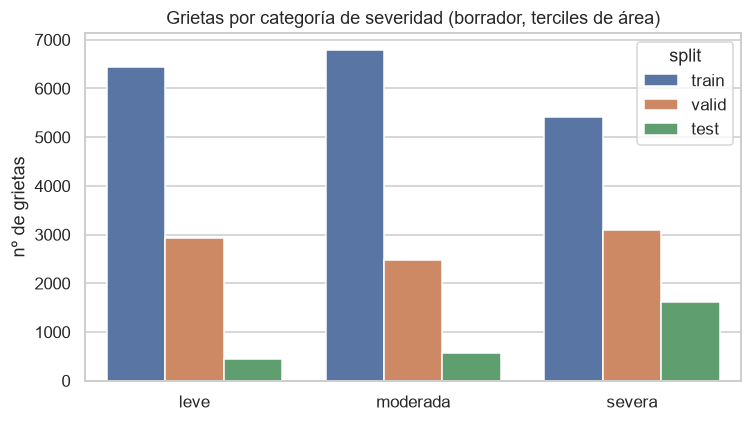

In [9]:
q = df["area_frac"].quantile([0.33, 0.66]).values
def severidad(a):
    if a < q[0]:   return "leve"
    if a < q[1]:   return "moderada"
    return "severa"

df["severidad"] = df["area_frac"].apply(severidad)
print(f"Umbrales de área (fracción): leve < {q[0]:.4f} <= moderada < {q[1]:.4f} <= severa")

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="severidad", order=["leve", "moderada", "severa"],
              hue="split", ax=ax)
ax.set_title("Grietas por categoría de severidad (borrador, terciles de área)")
ax.set_xlabel(""); ax.set_ylabel("nº de grietas")
plt.tight_layout(); plt.show()

### 2.7 Mapa de calor de posición de las grietas

¿Las grietas están centradas o distribuidas? Sirve para saber si conviene augmentation de traslación/crop.

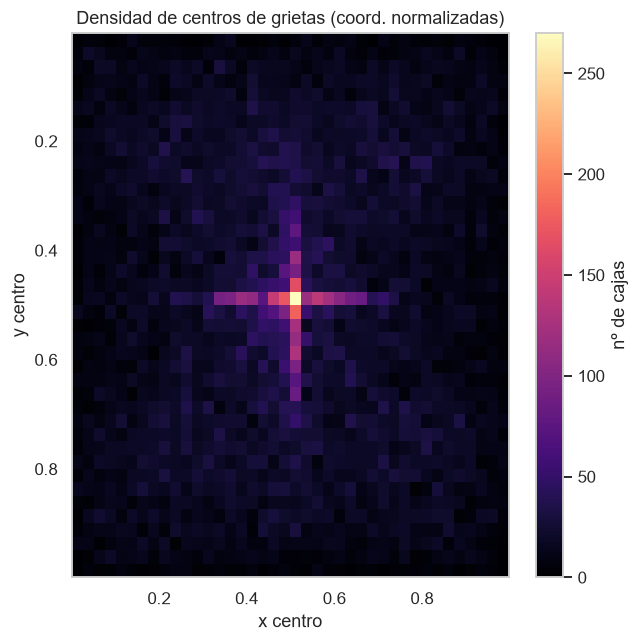

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
h = ax.hist2d(df["xc"], df["yc"], bins=40, cmap="magma")
ax.set_title("Densidad de centros de grietas (coord. normalizadas)")
ax.set_xlabel("x centro"); ax.set_ylabel("y centro")
ax.invert_yaxis()  # y=0 arriba, como en la imagen
fig.colorbar(h[3], ax=ax, label="nº de cajas")
plt.tight_layout(); plt.show()

### 2.8 Muestras con sus anotaciones

Dibujamos algunas imágenes de train con las cajas para control visual de la calidad de las etiquetas.

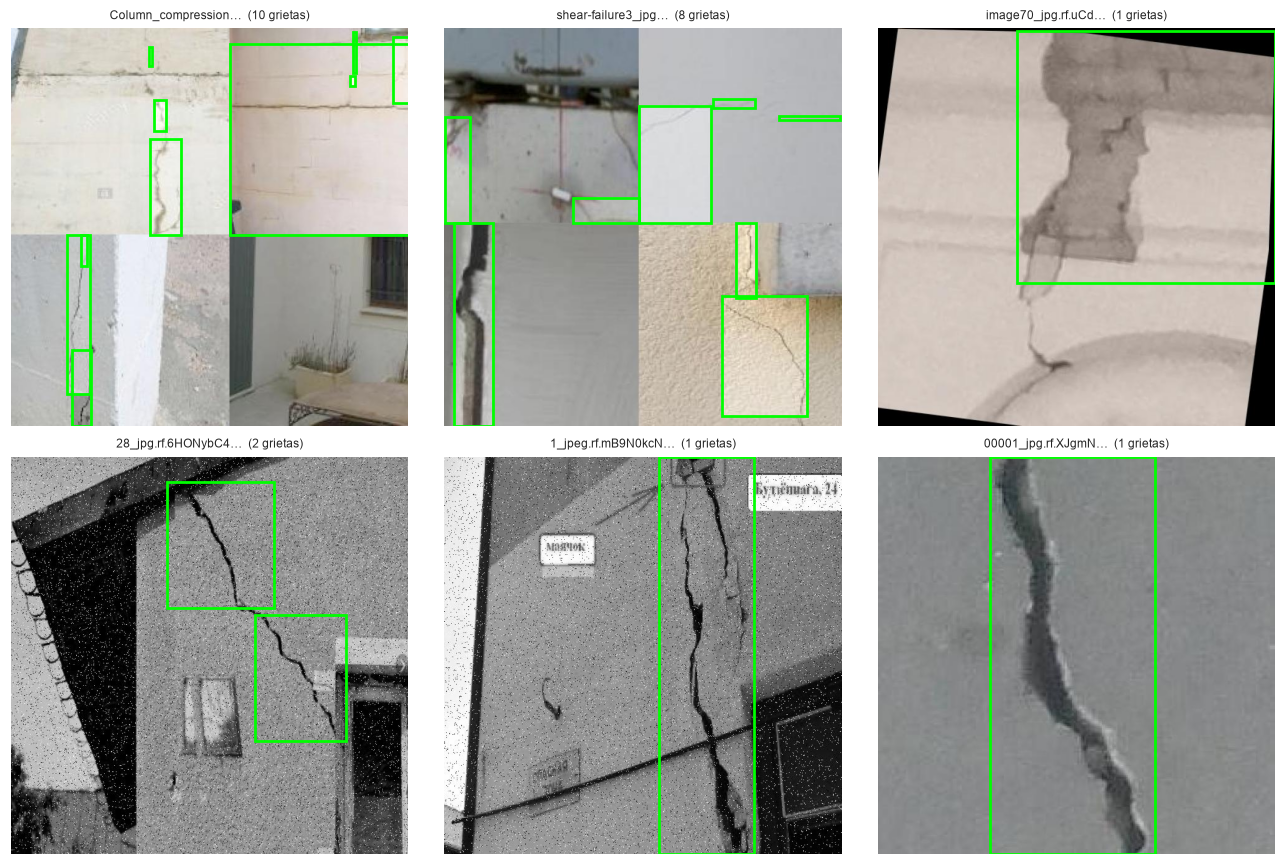

In [11]:
def show_samples(split="train", n=6, seed=0):
    sub = imgs[(imgs.split == split) & (imgs.n_boxes > 0)].sample(n, random_state=seed)
    cols = 3; rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).ravel()
    for ax, (_, row) in zip(axes, sub.iterrows()):
        img_path = DET_ROOT / split / "images" / row["file"]
        im = Image.open(img_path).convert("RGB")
        W, H = im.size
        ax.imshow(im)
        for (_, xc, yc, bw, bh) in read_yolo_label(
                DET_ROOT / split / "labels" / (Path(row["file"]).stem + ".txt")):
            x = (xc - bw / 2) * W; y = (yc - bh / 2) * H
            ax.add_patch(patches.Rectangle((x, y), bw * W, bh * H,
                         fill=False, edgecolor="lime", linewidth=1.8))
        ax.set_title(f"{row['file'][:18]}…  ({row['n_boxes']} grietas)", fontsize=8)
        ax.axis("off")
    for ax in axes[len(sub):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

show_samples("train", n=6, seed=42)

## 3. Dataset de segmentación (`dataset_1000`, DeepCrack) — resumen

Este dataset es de **segmentación semántica**: cada imagen tiene una máscara PNG (0 = fondo, 255 = grieta). No es el eje principal, pero puede enriquecer el paper con una sección de segmentación a nivel de píxel.

In [12]:
seg_info = []
if SEG_ROOT.exists():
    pairs = [("train", "train_img", "train_lab"), ("test", "test_img", "test_lab")]
    for name, imgd, labd in pairs:
        idir, ldir = SEG_ROOT / imgd, SEG_ROOT / labd
        if not idir.exists():
            continue
        files = [f for f in idir.iterdir() if f.suffix.lower() in IMG_EXTS]
        # fracción de píxeles de grieta en una muestra de máscaras
        fracs = []
        for f in files[:60]:
            m = np.array(Image.open(ldir / (f.stem + ".png")).convert("L"))
            fracs.append((m > 127).mean())
        seg_info.append({"split": name, "imagenes": len(files),
                         "%px_grieta_medio": round(np.mean(fracs) * 100, 2)})
    display(pd.DataFrame(seg_info))
else:
    print("dataset_1000 no encontrado, se omite.")

,split,imagenes,%px_grieta_medio
0,train,300,4.28
1,test,237,6.01


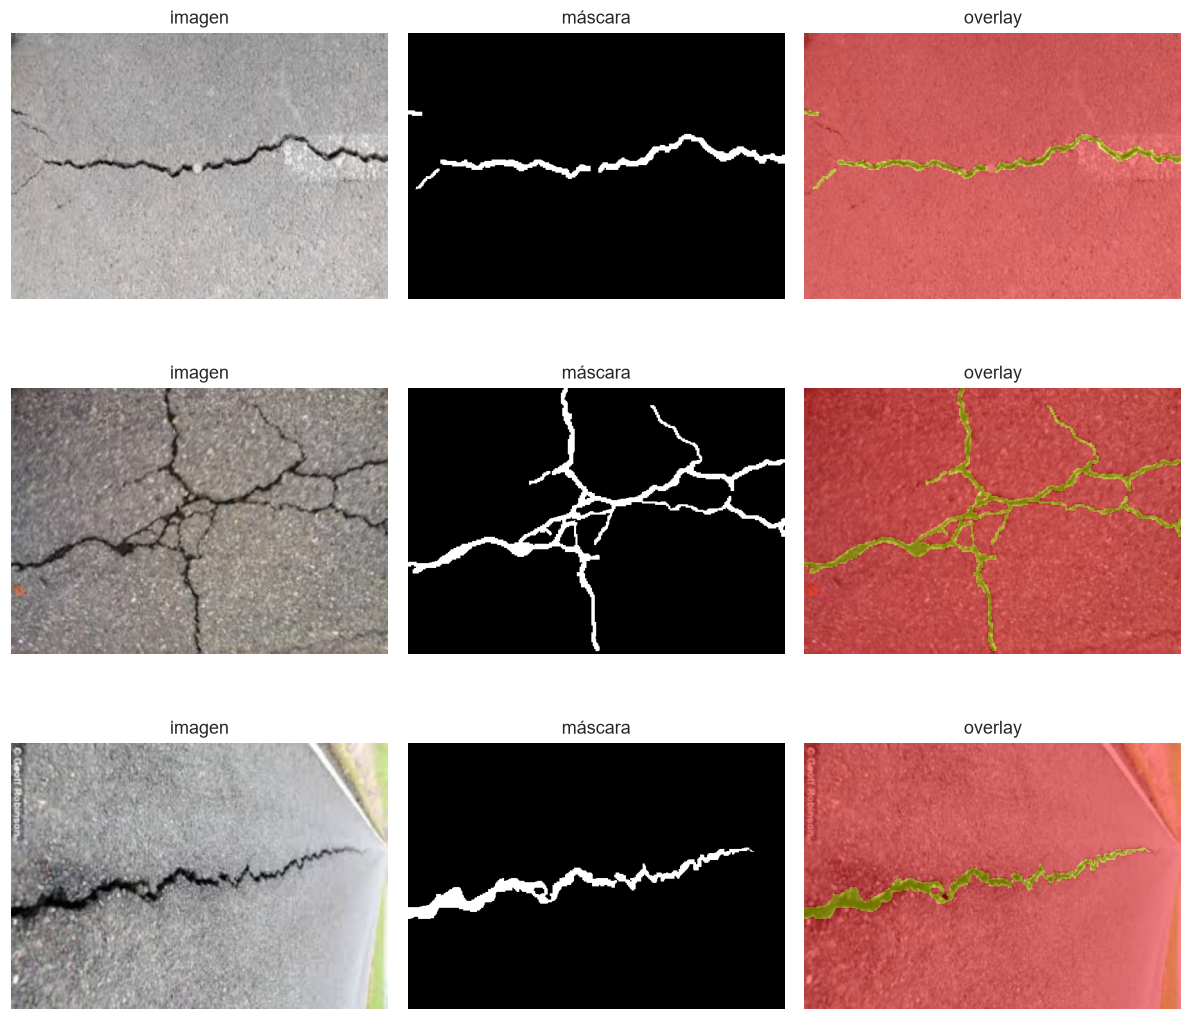

In [13]:
# Vista rápida: imagen + máscara superpuesta
if SEG_ROOT.exists():
    idir, ldir = SEG_ROOT / "train_img", SEG_ROOT / "train_lab"
    sample = sorted(f for f in idir.iterdir() if f.suffix.lower() in IMG_EXTS)[:3]
    fig, axes = plt.subplots(len(sample), 3, figsize=(11, 3.4 * len(sample)))
    axes = np.atleast_2d(axes)
    for i, f in enumerate(sample):
        im = Image.open(f).convert("RGB")
        m = Image.open(ldir / (f.stem + ".png")).convert("L")
        axes[i, 0].imshow(im); axes[i, 0].set_title("imagen"); axes[i, 0].axis("off")
        axes[i, 1].imshow(m, cmap="gray"); axes[i, 1].set_title("máscara"); axes[i, 1].axis("off")
        axes[i, 2].imshow(im); axes[i, 2].imshow(np.array(m), cmap="autumn", alpha=0.45)
        axes[i, 2].set_title("overlay"); axes[i, 2].axis("off")
    plt.tight_layout(); plt.show()

## 4. Conclusiones del EDA (para el paper)

> Completar tras ejecutar las celdas. Guía de lo que conviene reportar:

- **Volumen y particiones:** total de imágenes y su reparto train/valid/test (proporciones).
- **Clase única:** el problema es de detección de una sola clase (`crack`), no hay desbalance entre clases.
- **Densidad de grietas:** media/máximo de grietas por imagen y proporción de imágenes-fondo (sin grietas) → impacta en la métrica y en el manejo de negativos.
- **Escala de los objetos:** las grietas tienden a ser objetos {pequeños / alargados} → justifica `imgsz`, anchors y augmentation elegidos.
- **Homogeneidad de resolución:** todas a 640×640 → se puede entrenar a `imgsz=640` sin resize adicional.
- **Severidad por tamaño:** factible derivar 3 niveles (leve/moderada/severa) por área de la caja como capacidad complementaria.

*Fuentes: `datasets/dataset_9000` (Roboflow, detección) y `datasets/dataset_1000` (DeepCrack, segmentación).*